Import the required packages with their customary aliases as follows:

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

Using the pandas read_csv() method, read the GDP dataset into your notebook as a DataFrame called gdp_df. Take a look at the first few and last few rows to familiarize yourself with what is contained in this dataset.

In [5]:
gdp_df = pd.read_csv("../data/gdp_percapita.csv.csv")

In [6]:
gdp_df.head()

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN


In [7]:
gdp_df.tail()

,Country or Area,Year,Value,Value Footnotes
8460,Zimbabwe,1994,6010.742417,NaN
8461,Zimbabwe,1993,5509.083113,NaN
8462,Zimbabwe,1992,5532.037403,NaN
8463,Zimbabwe,1991,6254.274735,NaN
8464,Zimbabwe,1990,6082.842451,NaN


In [8]:
gdp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country or Area  8465 non-null   object 
 1   Year             8465 non-null   int64  
 2   Value            8465 non-null   float64
 3   Value Footnotes  0 non-null      float64
dtypes: float64(2), int64(1), object(1)
memory usage: 264.7+ KB


How many rows and columns are in gdp_df? What are the data types of each column?

In [9]:
gdp_df.shape

(8465, 4)

In [10]:
gdp_df.dtypes

Country or Area     object
Year                 int64
Value              float64
Value Footnotes    float64
dtype: object

Drop the Value Footnotes column and rename the remaining three to 'Country', 'Year', and 'GDP_Per_Capita'.

In [11]:
gdp_df = gdp_df.drop(columns=["Value Footnotes"])

In [12]:
gdp_df.columns = ["Country", "Year", "GDP_Per_Capita"]

In [13]:
gdp_df.head()

,Country,Year,GDP_Per_Capita
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144


How many countries have data for all years? Which countries are missing many years of data? Look at the number of observations per year. What do you notice?

In [14]:
total_years = gdp_df["Year"].nunique()
country_counts = gdp_df["Country"].value_counts()
countries_all_years = country_counts[country_counts == total_years]
len(countries_all_years)

226

In [15]:
total_years = gdp_df["Year"].nunique()
country_counts = gdp_df["Country"].value_counts()
missing_countries = country_counts[country_counts < total_years]
missing_countries.sort_values()

Country
Djibouti                     12
Sint Maarten (Dutch part)    16
Faroe Islands                17
Kosovo                       17
Cayman Islands               18
Turks and Caicos Islands     18
Virgin Islands (US)          21
Afghanistan                  24
CuraÃ§ao                     25
San Marino                   27
Montenegro                   28
Serbia                       30
West Bank and Gaza           31
Syrian Arab Republic         33
Palau                        34
Greenland                    34
Bhutan                       34
Tonga                        34
Somalia, Fed. Rep.           34
Tuvalu                       34
Lebanon                      34
Name: count, dtype: int64

In [16]:
gdp_df["Year"].value_counts().sort_index()

Year
1990    233
1991    234
1992    234
1993    234
1994    235
1995    236
1996    236
1997    238
1998    238
1999    238
2000    240
2001    240
2002    241
2003    241
2004    241
2005    241
2006    242
2007    243
2008    245
2009    246
2010    246
2011    246
2012    246
2013    247
2014    247
2015    247
2016    247
2017    247
2018    247
2019    247
2020    247
2021    247
2022    247
2023    245
2024    236
Name: count, dtype: int64

More countries have data available over time

Data collection/reporting improved

Recent years may be incomplete or not fully reported yet

In this question, you're going to create some plots to show the distribution of GDP per capita for the year 2020. Go to the Python Graph Gallery (https://www.python-graph-gallery.com/) and look at the different types of plots under the Distribution section. Create a histogram, a density plot, a boxplot, and a violin plot. What do you notice when you look at these plots? How do the plots compare and what information can you get out of one type that you can't necessarily get out of the others?

In [17]:
gdp_2020 = gdp_df[gdp_df["Year"] == 2020]

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

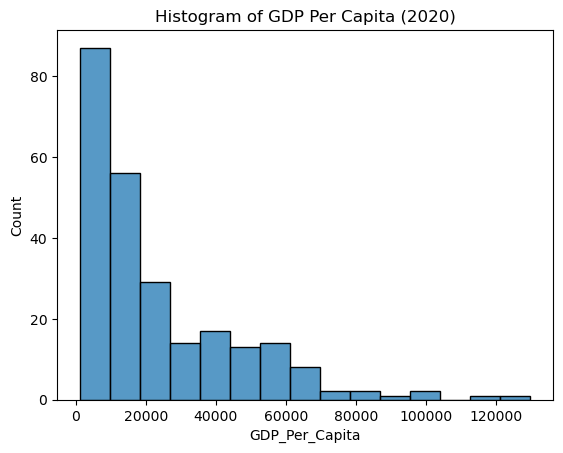

In [19]:
sns.histplot(gdp_2020["GDP_Per_Capita"])
plt.title("Histogram of GDP Per Capita (2020)")
plt.show()

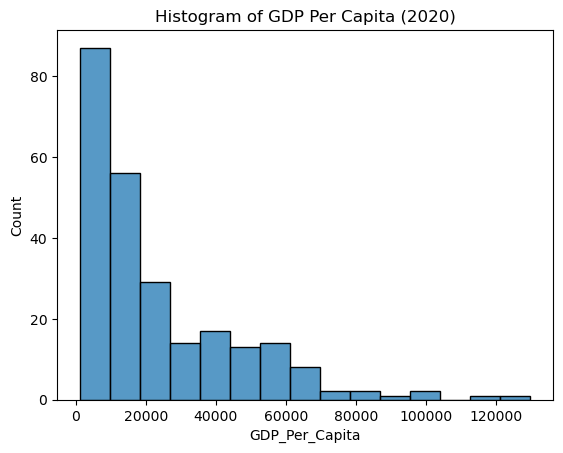

In [20]:
sns.histplot(gdp_2020["GDP_Per_Capita"])
plt.title("Histogram of GDP Per Capita (2020)")
plt.show()

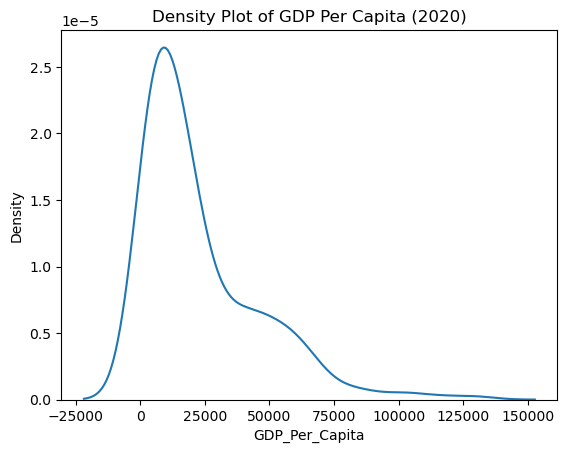

In [21]:
sns.kdeplot(gdp_2020["GDP_Per_Capita"])
plt.title("Density Plot of GDP Per Capita (2020)")
plt.show()

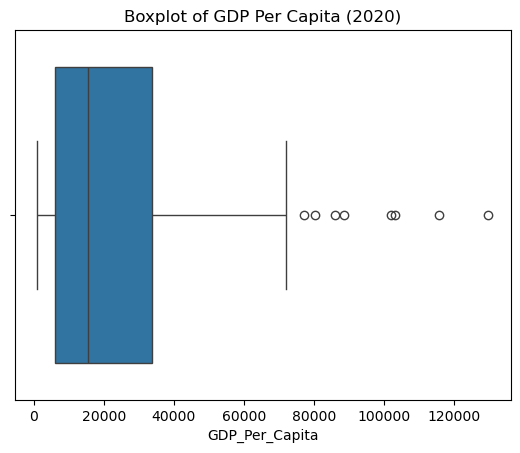

In [22]:
sns.boxplot(x=gdp_2020["GDP_Per_Capita"])
plt.title("Boxplot of GDP Per Capita (2020)")
plt.show()

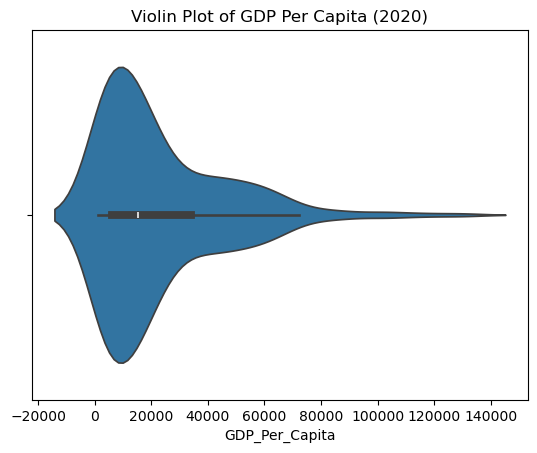

In [23]:
sns.violinplot(x=gdp_2020["GDP_Per_Capita"])
plt.title("Violin Plot of GDP Per Capita (2020)")
plt.show()

GDP per capita in 2020 is highly right-skewed, with most countries clustered at lower values and a small number of countries with extremely high values. The histogram and density plot show that most countries fall in the lower range, while the boxplot highlights extreme outliers. The violin plot shows that the data is heavily concentrated at the low end with a long tail toward higher values.”

What was the median GDP per capita value in 2020?

In [24]:
gdp_df[gdp_df["Year"] == 2020]["GDP_Per_Capita"].median()

15399.308958012449

For this question, you're going to create some visualizations to compare GDP per capita values for the years 1990, 2000, 2010, and 2020. Start by subsetting your data to just these 4 years into a new DataFrame named gdp_decades. Using this, create the following 4 plots:

A boxplot
A barplot (check out the Barplot with Seaborn section: https://www.python-graph-gallery.com/barplot/#Seaborn)
A scatterplot
A scatterplot with a trend line overlaid (see this regplot example: https://www.python-graph-gallery.com/42-custom-linear-regression-fit-seaborn)
Comment on what you observe has happened to GDP values over time and the relative strengths and weaknesses of each type of plot.

In [25]:
gdp_decades = gdp_df[gdp_df["Year"].isin([1990, 2000, 2010, 2020])]

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

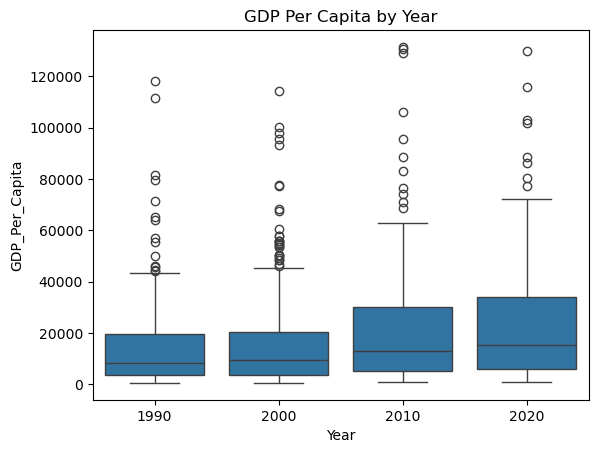

In [27]:
sns.boxplot(x="Year", y="GDP_Per_Capita", data=gdp_decades)
plt.title("GDP Per Capita by Year")
plt.show()

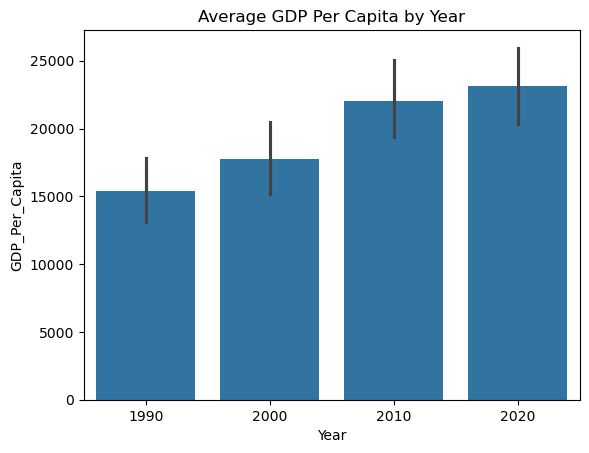

In [28]:
sns.barplot(x="Year", y="GDP_Per_Capita", data=gdp_decades)
plt.title("Average GDP Per Capita by Year")
plt.show()

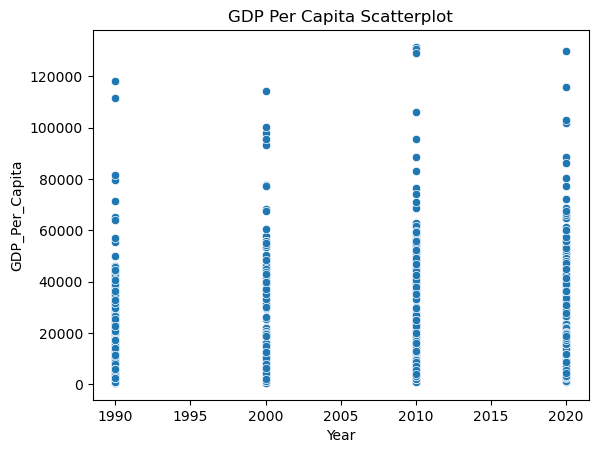

In [29]:
sns.scatterplot(x="Year", y="GDP_Per_Capita", data=gdp_decades)
plt.title("GDP Per Capita Scatterplot")
plt.show()

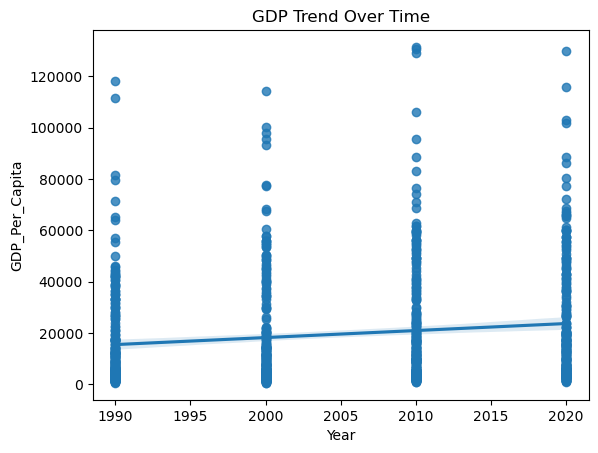

In [30]:
sns.regplot(x="Year", y="GDP_Per_Capita", data=gdp_decades)
plt.title("GDP Trend Over Time")
plt.show()

GDP per capita increases from 1990 to 2020, but most countries remain at lower values while a few high-income countries create large outliers. The boxplot shows spread and outliers, the barplot shows increasing averages, the scatterplot shows most values clustered low, and the trend line clearly shows overall growth.

Which country was the first to have a GDP per capita greater than $100,000?

In [31]:
gdp_df[gdp_df["GDP_Per_Capita"] > 100000].sort_values("Year").head()

,Country,Year,GDP_Per_Capita
8062,United Arab Emirates,1990,111377.046890
1037,Brunei Darussalam,1990,118163.683370
8061,United Arab Emirates,1991,106266.193694
1036,Brunei Darussalam,1991,118220.683595
8060,United Arab Emirates,1992,104206.754891


Which country had the highest GDP per capita in 2020? Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.

In [32]:
gdp_df[gdp_df["Year"] == 2020].sort_values("GDP_Per_Capita", ascending=False).head()

,Country,Year,GDP_Per_Capita
4629,Luxembourg,2020,129865.629988
6778,Singapore,2020,115893.042396
6371,Qatar,2020,103061.899445
3668,Ireland,2020,101968.554362
798,Bermuda,2020,88618.083068


In [33]:
top_country = "Luxembourg"

In [34]:
country_data = gdp_df[gdp_df["Country"] == top_country]

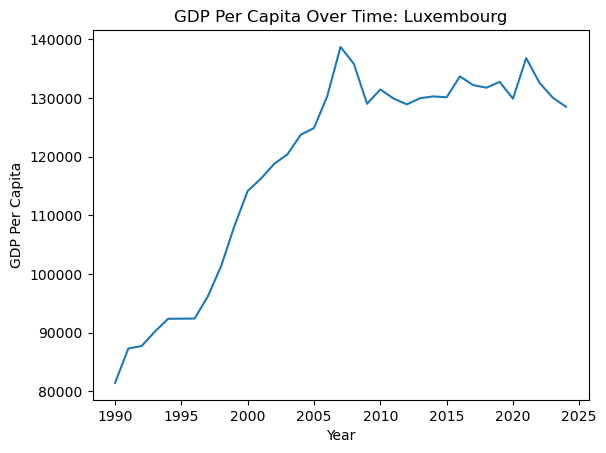

In [35]:
import matplotlib.pyplot as plt

plt.plot(country_data["Year"], country_data["GDP_Per_Capita"])
plt.title("GDP Per Capita Over Time: Luxembourg")
plt.xlabel("Year")
plt.ylabel("GDP Per Capita")
plt.show()

Which country had the lowest GDP per capita in 2020? Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.

In [36]:
gdp_df[gdp_df["Year"] == 2020] \
    .sort_values("GDP_Per_Capita") \
    .head()

,Country,Year,GDP_Per_Capita
1112,Burundi,2020,1030.770264
1375,Central African Republic,2020,1136.570530
1620,"Congo, Democratic Republic of",2020,1361.027911
6969,"Somalia, Fed. Rep.",2020,1396.055447
5357,Mozambique,2020,1466.124765


In [37]:
lowest_country = gdp_df[gdp_df["Year"] == 2020] \
    .sort_values("GDP_Per_Capita") \
    .iloc[0]["Country"]

lowest_country

'Burundi'

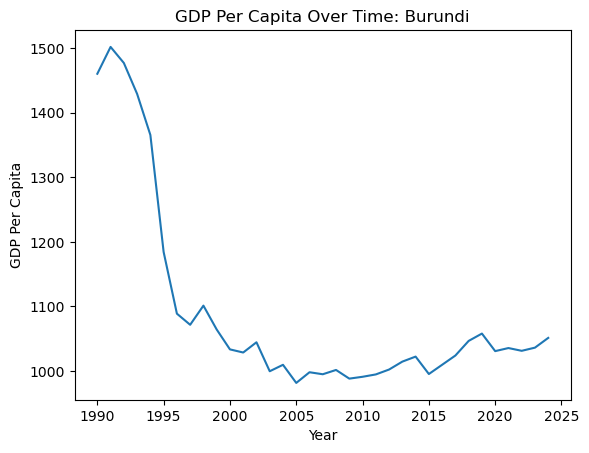

In [38]:
country_data = gdp_df[gdp_df["Country"] == lowest_country]
country_data = country_data.sort_values("Year")

import matplotlib.pyplot as plt

plt.plot(country_data["Year"], country_data["GDP_Per_Capita"])
plt.title(f"GDP Per Capita Over Time: {lowest_country}")
plt.xlabel("Year")
plt.ylabel("GDP Per Capita")
plt.show()

************Bonus question: Is it true in general that coutries had a higher GDP per capita in 2020 than in 1990? Which countries had lower GDP per capita in 2020 than in 1990?

In [39]:
gdp_1990 = gdp_df[gdp_df["Year"] == 1990]
gdp_2020 = gdp_df[gdp_df["Year"] == 2020]

In [40]:
merged = gdp_1990.merge(gdp_2020, on="Country", suffixes=("_1990", "_2020"))

In [41]:
lower_gdp = merged[merged["GDP_Per_Capita_2020"] < merged["GDP_Per_Capita_1990"]]

lower_gdp["Country"]

10                                        Aruba
14                                 Bahamas, The
17                                     Barbados
28                            Brunei Darussalam
31                                      Burundi
38                     Central African Republic
45                Congo, Democratic Republic of
46                           Congo, Republic of
72     Fragile and conflict affected situations
74                                        Gabon
86                                        Haiti
113                             Kyrgyz Republic
123                                     Liberia
124                                       Libya
131                                  Madagascar
146                                     Moldova
152                                       Nauru
184                                Saudi Arabia
199                                   St. Lucia
208                        Syrian Arab Republic
210                                  Taj

In [42]:
len(lower_gdp)

24

In [43]:
lower_gdp.head()

,Country,Year_1990,GDP_Per_Capita_1990,Year_2020,GDP_Per_Capita_2020
10,Aruba,1990,33063.001588,2020,30347.637185
14,"Bahamas, The",1990,33072.159613,2020,26452.695761
17,Barbados,1990,19613.248055,2020,17728.072925
28,Brunei Darussalam,1990,118163.683370,2020,80280.898064
31,Burundi,1990,1460.276459,2020,1030.770264


In general, GDP per capita increased from 1990 to 2020 for most countries. However, some countries experienced a decrease such as Aruba, Bahamas and Barbados.

Read in the internet use dataset into a DataFrame named internet_df. You will likely get errors when doing this. Check the arguments for the read_csv function to find ones that can help correct the errors (https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) Once you are able to read it in, take per a look at the top and bottom few rows to make sure that it has been read in correctly. Also, check the datatypes of the columns.

In [44]:
with open("../data/internet_use.csv", "r", encoding="utf-8", errors="replace") as f:
    lines = f.readlines()

print(lines[637])

Bhutan,2009,7.17,,,



In [45]:
internet_df = pd.read_csv("../data/internet_use.csv")

In [46]:
internet_df.head()

,Country or Area,Year,Value,Value Footnotes,Unnamed: 4,Unnamed: 5
0,Afghanistan,2019,17.6,1,NaN,NaN
1,Afghanistan,2018,16.8,2,NaN,NaN
2,Afghanistan,2017,13.5,3,NaN,NaN
3,Afghanistan,2016,11,4,NaN,NaN
4,Afghanistan,2015,8.26,4,NaN,NaN


In [47]:
internet_df.tail()

,Country or Area,Year,Value,Value Footnotes,Unnamed: 4,Unnamed: 5
6377,293,Estimated based on Survey's results. Populatio...,NaN,NaN,NaN,NaN
6378,294,Preliminary. Country estimate.,NaN,NaN,NaN,NaN
6379,295,18+. ITU estimate.,NaN,NaN,NaN,NaN
6380,296,ICT survey. Population age 11+,NaN,NaN,NaN,NaN
6381,297,Internet users aged 3 years and above who used...,NaN,NaN,NaN,NaN


In [48]:
internet_df.dtypes

Country or Area     object
Year                object
Value               object
Value Footnotes     object
Unnamed: 4         float64
Unnamed: 5          object
dtype: object

In [49]:
internet_df = internet_df.drop(columns=["Unnamed: 4", "Unnamed: 5"])

The dataset was successfully read in, as the columns and values appear correctly in the first few rows. However, some columns such as Year and Value were read in as text instead of numeric. Additionally, extra columns were created due to inconsistencies in the CSV file

Drop the Value Footnotes column and rename the remaining three to 'Country', 'Year', and 'Internet_Users_Pct'.

In [50]:
internet_df = internet_df.drop(columns=["Value Footnotes"])

In [51]:
internet_df.columns = ["Country", "Year", "Internet_Users_Pct"]

In [52]:
internet_df.head()

,Country,Year,Internet_Users_Pct
0,Afghanistan,2019,17.6
1,Afghanistan,2018,16.8
2,Afghanistan,2017,13.5
3,Afghanistan,2016,11
4,Afghanistan,2015,8.26


Look at the number of observations in this dataset per year. What do you notice?

In [53]:
internet_df["Year"].value_counts().sort_index()

Year
0.83                                                                                                1
0.84                                                                                                1
0.98                                                                                                1
1. Estimate 2. Individuals aged 6 and over.                                                         1
15 years and older. Last 12 months.                                                                 1
                                                                                                   ..
reference period is the last 12 months                                                              1
reference period: 3 months prior to questioning                                                     1
starting from 2014, the ISS asks about internet usage via a computer, or a mobile cellular phone    1
this figure includes all individuals who have access to the internet at home.

In [54]:
internet_df["Year"] = pd.to_numeric(internet_df["Year"], errors="coerce")

In [55]:
internet_df = internet_df.dropna(subset=["Year"])

In [56]:
internet_df["Year"] = internet_df["Year"].astype(int)

In [57]:
internet_df["Year"].value_counts().sort_index()

Year
0         3
1990    226
1991     39
1992     50
1993     66
1994     92
1995    141
1996    177
1997    188
1998    195
1999    207
2000    210
2001    212
2002    214
2003    208
2004    210
2005    212
2006    212
2007    217
2008    214
2009    214
2010    209
2011    214
2012    209
2013    203
2014    204
2015    203
2016    206
2017    205
2018    174
2019    185
2020    186
2021    186
2022    184
2023     11
Name: count, dtype: int64

The number of observations increases over time, indicating that more countries have internet usage data in later years. The data is most complete in the 2000s and 2010s. However, there is a sharp decrease in the most recent year 2023, suggesting incomplete data. There is also an invalid year 0, indicating some remaining data quality issues.

What is the first year to have a non-zero internet users percentage value?

In [58]:
internet_df["Internet_Users_Pct"] = pd.to_numeric(
    internet_df["Internet_Users_Pct"], errors="coerce"
)

In [59]:
internet_df[internet_df["Internet_Users_Pct"] > 0] \
    .sort_values("Year") \
    .head()

,Country,Year,Internet_Users_Pct
1570,Denmark,1990,0.097277
2892,Japan,1990,0.020294
306,Australia,1990,0.585095
2034,France,1990,0.052778
339,Austria,1990,0.130369


1990

How does the distribution of internet users percent differ for 2000 and 2014?

In [60]:
internet_2000 = internet_df[internet_df["Year"] == 2000]
internet_2014 = internet_df[internet_df["Year"] == 2014]

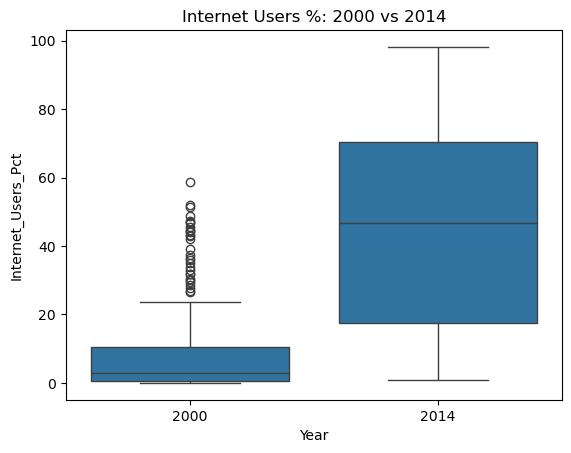

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Year", y="Internet_Users_Pct",
            data=internet_df[internet_df["Year"].isin([2000, 2014])])

plt.title("Internet Users %: 2000 vs 2014")
plt.show()

The distribution of internet users percentage is much higher in 2014 compared to 2000.

For how many countries was the percentage of internet users below 5% in 2014?

In [62]:
internet_df[
    (internet_df["Year"] == 2014) & 
    (internet_df["Internet_Users_Pct"] < 5)
]["Country"].nunique()

10

Merge the two DataFrames to one. Do this in a way that keeps all rows from each of the two DataFrames. Call the new DataFrame gdp_and_internet_use. Look at the first and last few rows to confirm that it merged correctly.

In [63]:
gdp_and_internet_use = pd.merge(
    gdp_df,
    internet_df,
    on=["Country", "Year"],
    how="outer"
)

In [64]:
gdp_and_internet_use.head()

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
0,141,0,NaN,NaN
1,142,0,NaN,NaN
2,159,0,NaN,NaN
3,Afghanistan,1990,NaN,0.0
4,Afghanistan,2000,1617.826475,NaN


In [65]:
gdp_and_internet_use.tail()

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
9778,Zimbabwe,2020,4527.719881,29.2986
9779,Zimbabwe,2021,4827.088694,32.4616
9780,Zimbabwe,2022,5036.761361,32.5615
9781,Zimbabwe,2023,5218.022665,NaN
9782,Zimbabwe,2024,5215.253011,NaN


The resulting DataFrame contains both GDP per capita and internet usage data, with missing values where data was not available in one of the datasets

Find the three countries with the highest internet users percentage in 2014. Use a seaborn FacetGrid (https://seaborn.pydata.org/generated/seaborn.FacetGrid.html) to compare how the GDP per capita has changed over time for these three countries. What do you notice?

In [66]:
gdp_and_internet_use[gdp_and_internet_use["Year"] == 2014] \
    .sort_values("Internet_Users_Pct", ascending=False) \
    .head(3)

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
4118,Iceland,2014,59133.270146,98.158
2978,Falkland (Malvinas) Islands,2014,NaN,97.600
883,Bermuda,2014,93042.273305,96.800


In [67]:
top_3_countries = ["Iceland", "Falkland (Malvinas) Islands", "Bermuda"]

In [68]:
top_3_data = gdp_and_internet_use[
    gdp_and_internet_use["Country"].isin(top_3_countries)
]

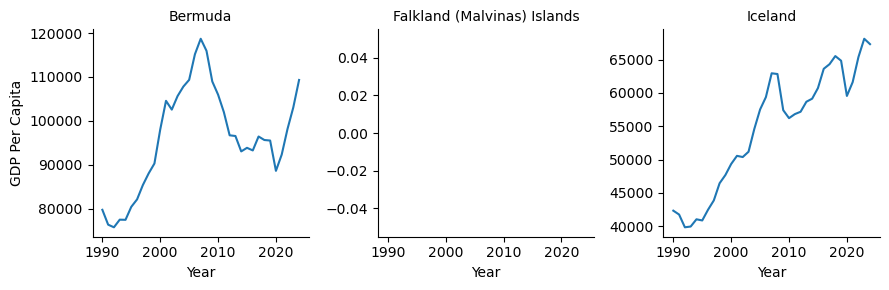

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(top_3_data, col="Country", col_wrap=3, sharey=False)
g.map(sns.lineplot, "Year", "GDP_Per_Capita")

g.set_axis_labels("Year", "GDP Per Capita")
g.set_titles("{col_name}")
plt.show()

The three countries with the highest internet usage in 2014 were Iceland, Falkland (Malvinas) Islands, and Bermuda. Iceland and Bermuda show increasing GDP per capita over time, indicating economic growth. However, the Falkland Islands have missing GDP data, making it difficult to observe a trend.

Subset gdp_and_internet_use to just the year 2014. Save this as a new dataframe named gdp_and_internet_use_2014.

In [70]:
gdp_and_internet_use_2014 = gdp_and_internet_use[
    gdp_and_internet_use["Year"] == 2014
]

In [71]:
gdp_and_internet_use_2014.head()

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
18,Afghanistan,2014,3017.942544,7.0
52,Africa Eastern and Southern,2014,4185.238411,NaN
87,Africa Western and Central,2014,6174.703316,NaN
122,Albania,2014,12718.284760,54.3
157,Algeria,2014,15073.762940,29.5


Create a plot which compares Internet Users Percentage and GDP per Capita for the year 2014. What do you notice from this plot? If you see any unusual points, investigate them.

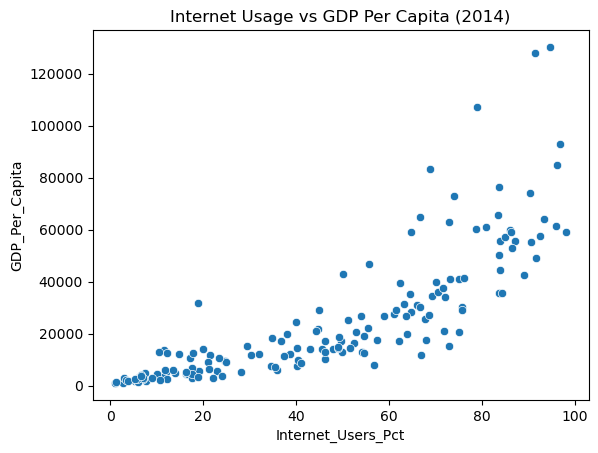

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x="Internet_Users_Pct",
    y="GDP_Per_Capita",
    data=gdp_and_internet_use_2014
)

plt.title("Internet Usage vs GDP Per Capita (2014)")
plt.show()

The plot shows a positive relationship between internet usage and GDP per capita. Most countries cluster at low values, while a few countries with very high GDP per capita appear as outliers at high internet usage levels.

Stretch Question: Use the qcut function from pandas (https://pandas.pydata.org/docs/reference/api/pandas.qcut.html) to divide countries in gdp_per_capita_2014 into three groups based on their GDP per capita values. Label these groups as "Low", "Medium", and "High". Put these labels in a new column, named "GDP_group".

In [76]:
gdp_and_internet_use_2014.loc[:, "GDP_group"] = pd.qcut(
    gdp_and_internet_use_2014["GDP_Per_Capita"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [77]:
gdp_and_internet_use_2014.head()

,Country,Year,GDP_Per_Capita,Internet_Users_Pct,GDP_group
18,Afghanistan,2014,3017.942544,7.0,Low
52,Africa Eastern and Southern,2014,4185.238411,NaN,Low
87,Africa Western and Central,2014,6174.703316,NaN,Low
122,Albania,2014,12718.284760,54.3,Medium
157,Algeria,2014,15073.762940,29.5,Medium


Stretch Question: How does the median internet users percentage compare for the three gdp groups?

In [78]:
gdp_and_internet_use_2014.groupby("GDP_group")["Internet_Users_Pct"].median()

C:\Users\Student\AppData\Local\Temp\ipykernel_23360\3205956616.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdp_and_internet_use_2014.groupby("GDP_group")["Internet_Users_Pct"].median()


GDP_group
Low       11.6000
Medium    44.8033
High      75.3355
Name: Internet_Users_Pct, dtype: float64

Countries in the High GDP group have significantly higher median internet usage compared to Medium and Low groups.